# Rewards Statistical Analysis

This notebook performs a comprehensive statistical analysis of the rewards data from episode 3.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set the style for better visualizations
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')

In [4]:
# Load the rewards data
rewards_df = pd.read_csv('data/episode-101/monitor/rewards.csv')

# Display basic information about the dataset
print(f"Total number of rewards: {len(rewards_df)}")
rewards_df.describe()

Total number of rewards: 61056


,reward
count,61056.000000
mean,-226.196721
std,234.924112
min,-1062.742477
25%,-364.880257
50%,-129.726414
75%,-47.523345
max,-0.000034


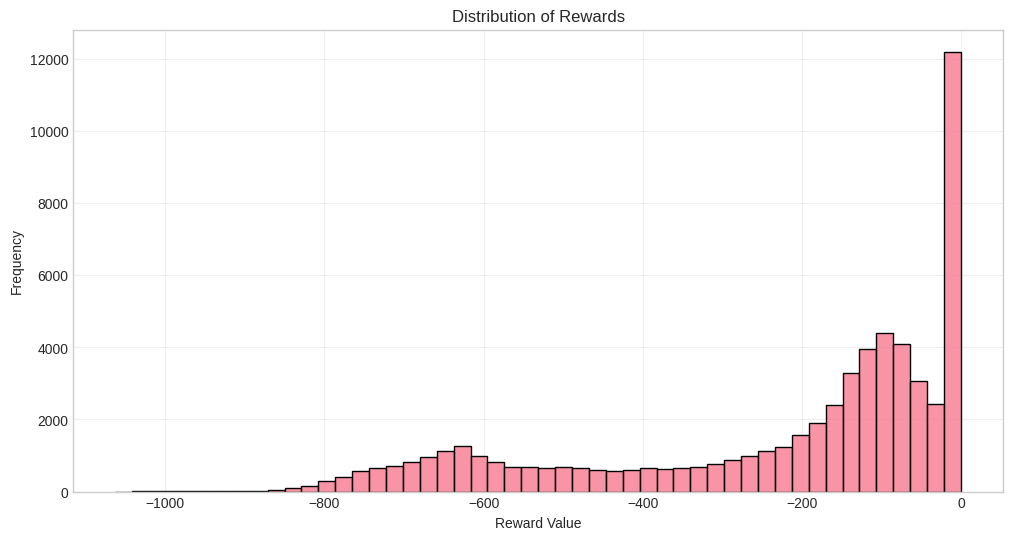

In [5]:
# Create a histogram of rewards
plt.figure(figsize=(12, 6))
sns.histplot(data=rewards_df, x='reward', bins=50)
plt.title('Distribution of Rewards')
plt.xlabel('Reward Value')
plt.ylabel('Frequency')
plt.grid(True, alpha=0.3)
plt.show()

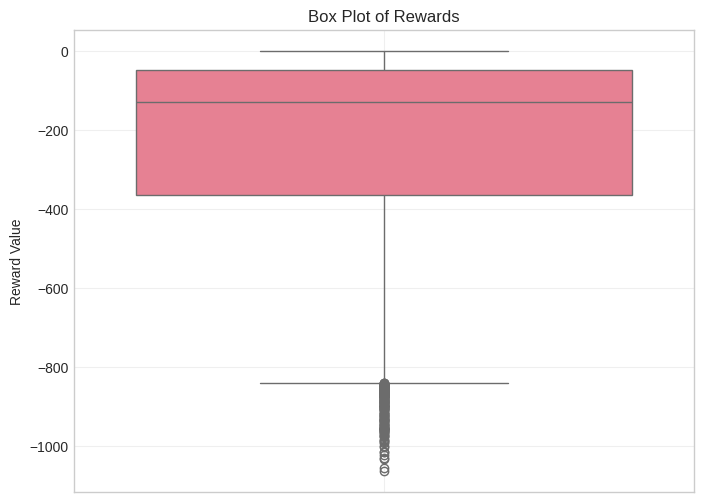

In [6]:
# Create a box plot to visualize the distribution
plt.figure(figsize=(8, 6))
sns.boxplot(data=rewards_df, y='reward')
plt.title('Box Plot of Rewards')
plt.ylabel('Reward Value')
plt.grid(True, alpha=0.3)
plt.show()

In [7]:
# Calculate and display additional statistics
print("Additional Statistics:")
print(f"Median reward: {rewards_df['reward'].median():.2f}")
print(f"Mode reward: {rewards_df['reward'].mode().values[0]:.2f}")
print(f"Standard deviation: {rewards_df['reward'].std():.2f}")
print(f"Skewness: {rewards_df['reward'].skew():.2f}")
print(f"Kurtosis: {rewards_df['reward'].kurtosis():.2f}")

Additional Statistics:
Median reward: -129.73
Mode reward: -71.46
Standard deviation: 234.92
Skewness: -1.02
Kurtosis: -0.26


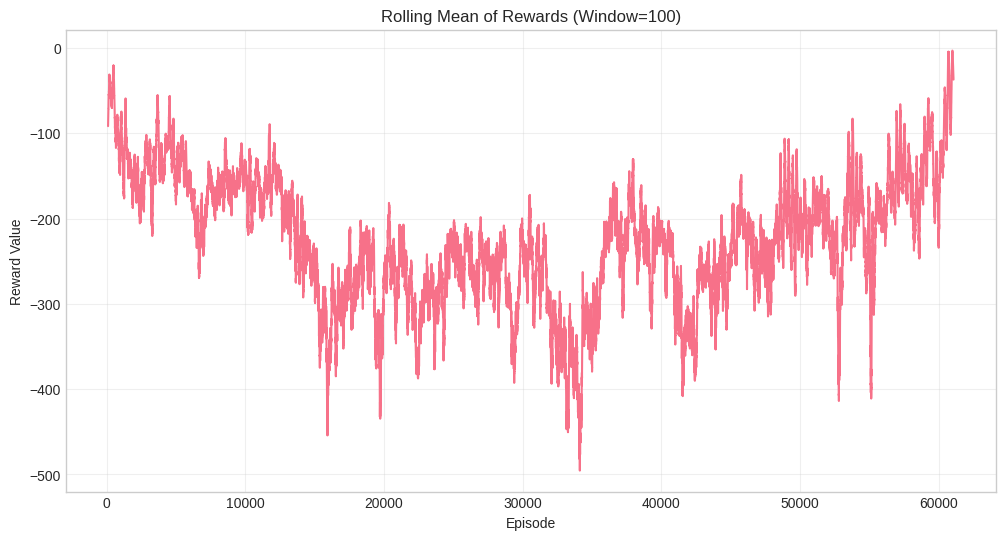

In [8]:
# Create a rolling mean plot to see the trend
plt.figure(figsize=(12, 6))
rewards_df['rolling_mean'] = rewards_df['reward'].rolling(window=100).mean()
plt.plot(rewards_df['rolling_mean'])
plt.title('Rolling Mean of Rewards (Window=100)')
plt.xlabel('Episode')
plt.ylabel('Reward Value')
plt.grid(True, alpha=0.3)
plt.show()

In [9]:
# Calculate and display reward statistics by quartiles
quartiles = rewards_df['reward'].quantile([0.25, 0.5, 0.75])
print("\nReward Quartiles:")
print(f"25th percentile: {quartiles[0.25]:.2f}")
print(f"50th percentile (median): {quartiles[0.5]:.2f}")
print(f"75th percentile: {quartiles[0.75]:.2f}")

# Calculate interquartile range
iqr = quartiles[0.75] - quartiles[0.25]
print(f"\nInterquartile Range (IQR): {iqr:.2f}")

# Identify potential outliers
lower_bound = quartiles[0.25] - 1.5 * iqr
upper_bound = quartiles[0.75] + 1.5 * iqr
outliers = rewards_df[(rewards_df['reward'] < lower_bound) | (rewards_df['reward'] > upper_bound)]
print(f"\nNumber of potential outliers: {len(outliers)}")


Reward Quartiles:
25th percentile: -364.88
50th percentile (median): -129.73
75th percentile: -47.52

Interquartile Range (IQR): 317.36

Number of potential outliers: 183


## Summary of Analysis

This analysis provides insights into the distribution and characteristics of the rewards data:

1. Basic statistics (mean, median, standard deviation)
2. Distribution visualization through histograms and box plots
3. Trend analysis using rolling means
4. Outlier detection
5. Additional statistical measures (skewness, kurtosis)

The visualizations and statistics help understand the reward distribution and identify any patterns or anomalies in the data.